# 静态场景 - 密度扫描实验
固定业务比例，扫描不同总密度下的性能表现

## 初始化环境

In [1]:
import sys
sys.path.insert(0, '.')

from algo.logger import reset_logger
reset_logger()

In [2]:
from dataclasses import replace
from pathlib import Path
from typing import Dict
from copy import deepcopy
import math
import torch
import yaml
import os
import numpy as np
from collections import OrderedDict
import importlib
from matplotlib import pyplot as plt

from algo import HPPOConfig, build_hppo_modules, train_hppo
from algo.logger import get_logger, setup_logger
from env import (
    MACSimulatorConfig,
    SatelliteMACEnv,
    SatelliteMACEnvConfig,
    default_simulator_config,
    build_gym_env,
)
import matplotlib.font_manager as font_manager
import scienceplots
plt.style.use(['science', 'no-latex'])
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['Noto Sans SC',]

# 导入评估工具（包括static_sensitivity_config和load_yaml_config）
from utils.evaluate import (
    static_sensitivity_config,
    train_and_evaluate_scenario,
    print_results_summary,
    load_yaml_config
)
import baseline
importlib.reload(baseline)
from baseline import run_episode


## 密度扫描配置生成

In [3]:
def run_density_sweep_experiment():
    """
    密度扫描实验：固定业务比例，扫描总密度
    用于绘制：Throughput vs. Density 曲线
    """
    # 1. 定义几个固定的业务混合模式
    traffic_mixes = {
        "CBRA_Heavy": {'cbra': 0.7, 'pbra': 0.2, 'cfra': 0.1},
    }

    # 2. 定义要扫描的密度范围
    densities = [5.0, 10.0, 30.0, 50.0,100.0]
    configs = []

    print("--- Generating Density Sweep Configs ---")
    for mix_name, ratios in traffic_mixes.items():
        for d in densities:
            cfg = static_sensitivity_config(
                total_density=d,
                cbra_ratio=ratios['cbra'],
                pbra_ratio=ratios['pbra'],
                cfra_ratio=ratios['cfra']
            )
            label = f"{mix_name}_D{int(d)}"
            configs.append((label, cfg))
            print(f"Generated: [{label}]")

    return configs

# 生成配置
density_sweep_configs = run_density_sweep_experiment()
print(f"\n总共生成 {len(density_sweep_configs)} 个密度扫描场景配置")

--- Generating Density Sweep Configs ---
Generated: [CBRA_Heavy_D5]
Generated: [CBRA_Heavy_D10]
Generated: [CBRA_Heavy_D30]
Generated: [CBRA_Heavy_D50]
Generated: [CBRA_Heavy_D100]

总共生成 5 个密度扫描场景配置


## 加载训练配置

In [4]:
CONFIG_PATH = Path("conf/default.yaml")

raw_config = load_yaml_config(CONFIG_PATH)
seed = int(raw_config.get("seed", 20251202))
torch.manual_seed(seed)

log_section = raw_config.get("logging", {})
log_file = f"logs/{seed}_density_sweep_CBRA.log"
try:
    os.remove(log_file) if os.path.exists(log_file) else None
except Exception as e:
    print(f"Warning: Could not remove existing log file: {e}")
log_level = log_section.get("level", "INFO")
setup_logger(log_file, log_level)
my_logger = get_logger()
my_logger.info(f"Logger initialized for density sweep experiment")

# 环境配置
env_section = dict(raw_config.get("environment", {}))
algo_section = raw_config.get("algorithm", {})
env_section.setdefault("noise_scale", 0.01)

simulator_config = default_simulator_config()
num_slots_per_step = int(env_section.get("num_slots_per_step", 10))

env_config = SatelliteMACEnvConfig(
    num_slots_per_step=num_slots_per_step,
    decision_horizon=80,
    preamble_delta_range=int(env_section.get("preamble_delta_range", 2)),
    flatten_observation=bool(env_section.get("flatten_observation", True)),
    simulator_config=simulator_config,
)

num_envs = 8
env_backend = "parallel"

train_config = HPPOConfig(
    frames_per_batch=2560,
    mini_batch_size=256,
    rollout_epochs=4,
    max_iterations=250,  # 静态场景训练100轮
    gamma=float(algo_section.get("gamma", 0.99)),
    gae_lambda=float(algo_section.get("gae_lambda", 0.95)),
    clip_epsilon=0.2,
    entropy_coeff=0.1,
    actor_lr=3e-4,
    critic_lr=3e-4,
    device=torch.device(algo_section.get("device", "cpu")),
)

my_logger.info(f"Config ready | seed={seed} num_envs={num_envs}")
print(f"配置加载完成: {len(density_sweep_configs)} 个场景待训练")


2025-12-03 15:40:11 | INFO     | Logger initialized for density sweep experiment


Loaded configuration from conf\default.yaml
配置加载完成: 5 个场景待训练


2025-12-03 15:40:11 | INFO     | Config ready | seed=42 num_envs=8


## 执行密度扫描训练

In [5]:
# 全局结果存储
all_scenarios_results = OrderedDict()

print(f"\n{'='*80}")
print(f"开始批量训练 {len(density_sweep_configs)} 个密度扫描场景")
print(f"{'='*80}\n")

for idx, (label, sim_config) in enumerate(density_sweep_configs):
    print(f"\n[{idx+1}/{len(density_sweep_configs)}] 当前场景: {label}")
    try:
        result = train_and_evaluate_scenario(
            scenario_name=label,
            sim_config=sim_config,
            env_config=env_config,
            train_config=train_config,
            build_env_func=build_gym_env,
            build_modules_func=build_hppo_modules,
            train_func=train_hppo,
            run_episode_func=run_episode,
            logger=my_logger,
            num_envs=num_envs,
            env_backend=env_backend,
            num_episodes=20,
            seed=seed
        )
        all_scenarios_results[label] = result
    except Exception as e:
        print(f"场景 {label} 训练失败: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*80}")
print(f"所有场景训练完成!")
print(f"成功训练场景数: {len(all_scenarios_results)}/{len(density_sweep_configs)}")
print(f"{'='*80}")

# 显示结果摘要
print_results_summary(all_scenarios_results)


开始批量训练 5 个密度扫描场景


[1/5] 当前场景: CBRA_Heavy_D5

开始训练场景: CBRA_Heavy_D5
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=80, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D5.0_C0.7_P0.2_F0.1', cbra_density=3.5, pbra_density=1.0, cfra_density=0.5),), segments=(RegionSegment(region_name='static_D5.0_C0.7_P0.2_F0.1', length=11.0),), total_preambles=64, base_preamble_split=(27, 27, 10), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.05, reward_weights={'throughput': 1.0, 'collision': -0.3}, backoff_strategy=BackoffStrategyConfig(low=BackoffWindow(min_steps=0, max_steps=4), medium=BackoffWindow(min_steps=2, max_steps=10), high=BackoffWindow(min_steps=6, max_steps=18), collision_threshold_medium=0.08, collision_threshold_high=0.16, max_backlog_steps=48)), preamble_delta_range=2, flatten_observation=True)
config 2
2025-12-03 15:40:11,206 [torchrl][INFO]    The info_dict_reader does not have specs. The on

e:\CourseData\博士\二上\i3c\20251027-星网总结报告\hppo-mac\.venv\Lib\site-packages\torchrl\envs\batched_envs.py:2318: UserWarning: Sending a seeded ParallelEnv to another device requires re-seeding it. Re-seeding envs to [42, 1445067485, 3334094167, 3585780589, 2792652595, 3481998204, 395747745, 79072177].
  warn(
2025-12-03 15:40:16 | INFO     | Starting PPO training for scenario: CBRA_Heavy_D5


  iter=0000, reward=0.2591
  iter=0010, reward=0.3718
  iter=0020, reward=0.5924
  iter=0030, reward=0.7932
  iter=0040, reward=0.9188
  iter=0050, reward=1.0268
  iter=0060, reward=1.1410
  iter=0070, reward=1.2132
  iter=0080, reward=1.2533
  iter=0090, reward=1.3146
  iter=0100, reward=1.3297
  iter=0110, reward=1.3666
  iter=0120, reward=1.4173
  iter=0130, reward=1.4282
  iter=0140, reward=1.4358
  iter=0150, reward=1.4242
  iter=0160, reward=1.4432
  iter=0170, reward=1.4844
  iter=0180, reward=1.4601
  iter=0190, reward=1.5068
  iter=0200, reward=1.4982
  iter=0210, reward=1.5025
  iter=0220, reward=1.5728
  iter=0230, reward=1.5241
  iter=0240, reward=1.5341
训练完成: 最佳奖励=1.6202 (迭代248)
  评估最佳模型...
  评估最后一轮模型...
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=80, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D5.0_C0.7_P0.2_F0.1', cbra_density=3.5, pbra_density=1.0, cfra_density=0.5),), segments=(RegionSegment(region_name='static_D5.0_

2025-12-03 16:10:31 | INFO     | Starting PPO training for scenario: CBRA_Heavy_D10


  iter=0000, reward=-0.1299
  iter=0010, reward=0.5319
  iter=0020, reward=0.7248
  iter=0030, reward=0.9590
  iter=0040, reward=1.0467
  iter=0050, reward=1.2235
  iter=0060, reward=1.4005
  iter=0070, reward=1.3963
  iter=0080, reward=1.4958
  iter=0090, reward=1.5153
  iter=0100, reward=1.5555
  iter=0110, reward=1.6010
  iter=0120, reward=1.6797
  iter=0130, reward=0.3123
  iter=0140, reward=0.6348
  iter=0150, reward=0.9805
  iter=0160, reward=1.2700
  iter=0170, reward=1.4352
  iter=0180, reward=1.6293
  iter=0190, reward=1.6773
  iter=0200, reward=1.6936
  iter=0210, reward=1.6818
  iter=0220, reward=1.7749
  iter=0230, reward=1.7523
  iter=0240, reward=1.7722
训练完成: 最佳奖励=1.8045 (迭代248)
  评估最佳模型...
  评估最后一轮模型...
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=80, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D10.0_C0.7_P0.2_F0.1', cbra_density=7.0, pbra_density=2.0, cfra_density=1.0),), segments=(RegionSegment(region_name='static_D10

...

  iter=0000, reward=-0.3493
  iter=0010, reward=0.1458
  iter=0020, reward=0.4678
  iter=0030, reward=0.5939
  iter=0040, reward=0.9021
  iter=0050, reward=1.2413
  iter=0060, reward=1.3586
  iter=0070, reward=0.7107
  iter=0080, reward=1.1823
  iter=0090, reward=1.4114
  iter=0100, reward=1.4514
  iter=0110, reward=1.6545
  iter=0120, reward=1.7865
  iter=0130, reward=1.7488
  iter=0140, reward=1.8400
  iter=0150, reward=1.5237
  iter=0160, reward=1.7638
  iter=0170, reward=1.6060
  iter=0180, reward=1.8645
  iter=0190, reward=1.9346
  iter=0200, reward=1.9148
  iter=0210, reward=1.9789
  iter=0220, reward=2.0072
  iter=0230, reward=2.0297
  iter=0240, reward=2.0390
训练完成: 最佳奖励=2.0720 (迭代238)
  评估最佳模型...
  评估最后一轮模型...
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=80, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D30.0_C0.7_P0.2_F0.1', cbra_density=21.0, pbra_density=6.0, cfra_density=3.0),), segments=(RegionSegment(region_name='static_D3

2025-12-03 16:43:26 | INFO     | Starting PPO training for scenario: CBRA_Heavy_D50


  iter=0000, reward=-0.4320
  iter=0010, reward=-0.1256
  iter=0020, reward=0.2840
  iter=0030, reward=0.4770
  iter=0040, reward=0.7351
  iter=0050, reward=0.9842
  iter=0060, reward=1.3314
  iter=0070, reward=1.4591
  iter=0080, reward=1.3289
  iter=0090, reward=1.6301
  iter=0100, reward=1.1849
  iter=0110, reward=1.3641
  iter=0120, reward=1.5075
  iter=0130, reward=1.5924
  iter=0140, reward=1.1119
  iter=0150, reward=1.6337
  iter=0160, reward=1.6701
  iter=0170, reward=1.7676
  iter=0180, reward=1.7957
  iter=0190, reward=1.8704
  iter=0200, reward=1.7233
  iter=0210, reward=1.8977
  iter=0220, reward=-0.2680
  iter=0230, reward=0.1361
  iter=0240, reward=0.5208
训练完成: 最佳奖励=1.9408 (迭代215)
  评估最佳模型...
  评估最后一轮模型...
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=80, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D50.0_C0.7_P0.2_F0.1', cbra_density=35.0, pbra_density=10.0, cfra_density=5.0),), segments=(RegionSegment(region_name='static

2025-12-03 17:02:26 | INFO     | Starting PPO training for scenario: CBRA_Heavy_D100


  iter=0000, reward=-0.5295
  iter=0010, reward=-0.3610
  iter=0020, reward=-0.1985
  iter=0030, reward=-0.1538
  iter=0040, reward=-0.0442
  iter=0050, reward=0.1515
  iter=0060, reward=0.3591
  iter=0070, reward=0.0313
  iter=0080, reward=0.3338
  iter=0090, reward=0.4243
  iter=0100, reward=0.5033
  iter=0110, reward=0.7171
  iter=0120, reward=1.1355
  iter=0130, reward=1.4896
  iter=0140, reward=1.4128
  iter=0150, reward=1.7127
  iter=0160, reward=1.7355
  iter=0170, reward=-0.2861
  iter=0180, reward=-0.0496
  iter=0190, reward=0.3003
  iter=0200, reward=0.6672
  iter=0210, reward=0.9893
  iter=0220, reward=1.2318
  iter=0230, reward=1.6155
  iter=0240, reward=1.5219
训练完成: 最佳奖励=1.8390 (迭代165)
  评估最佳模型...
  评估最后一轮模型...
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=80, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D100.0_C0.7_P0.2_F0.1', cbra_density=70.0, pbra_density=20.0, cfra_density=10.0),), segments=(RegionSegment(region_name='

## 可视化密度扫描结果

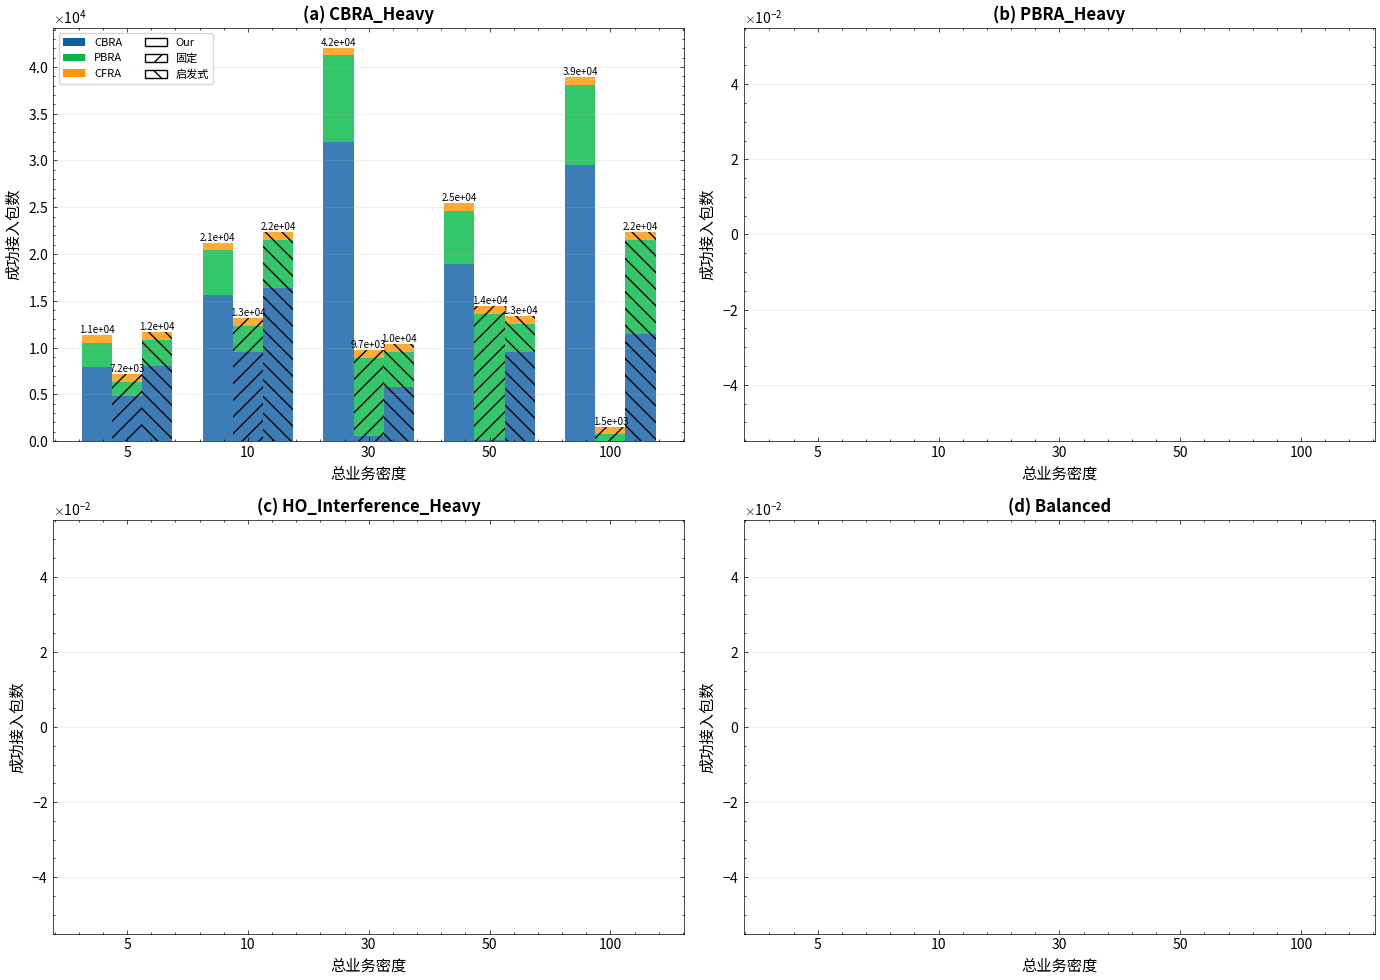

密度扫描对比图已保存到: output/static/density_sweep_comparison.svg


In [7]:
def plot_density_sweep_results():
    """绘制密度扫描实验结果 - 2x2布局，每个流量模式一个子图"""
    traffic_mixes = ["CBRA_Heavy", "PBRA_Heavy", "HO_Interference_Heavy", "Balanced"]
    densities = [5.0, 10.0, 30.0, 50.0, 100.0]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for mix_idx, mix_name in enumerate(traffic_mixes):
        ax = axes[mix_idx // 2, mix_idx % 2]

        # 收集数据
        ppo_cbra = []
        ppo_pbra = []
        ppo_cfra = []
        fixed_cbra = []
        fixed_pbra = []
        fixed_cfra = []
        heuristic_cbra = []
        heuristic_pbra = []
        heuristic_cfra = []

        for d in densities:
            label = f"{mix_name}_D{int(d)}"
            if label in all_scenarios_results:
                result = all_scenarios_results[label]

                # PPO最佳模型
                ppo_cbra.append(result['eval_results_last']['eval_success_cbra'])
                ppo_pbra.append(result['eval_results_last']['eval_success_pbra'])
                ppo_cfra.append(result['eval_results_last']['eval_success_cfra'])

                # 固定分配
                fixed_cbra.append(result['baseline_results']['固定分配']['success_cbra'])
                fixed_pbra.append(result['baseline_results']['固定分配']['success_pbra'])
                fixed_cfra.append(result['baseline_results']['固定分配']['success_cfra'])

                # 启发式算法
                heuristic_cbra.append(result['baseline_results']['启发式算法']['success_cbra'])
                heuristic_pbra.append(result['baseline_results']['启发式算法']['success_pbra'])
                heuristic_cfra.append(result['baseline_results']['启发式算法']['success_cfra'])
            else:
                ppo_cbra.append(0)
                ppo_pbra.append(0)
                ppo_cfra.append(0)
                fixed_cbra.append(0)
                fixed_pbra.append(0)
                fixed_cfra.append(0)
                heuristic_cbra.append(0)
                heuristic_pbra.append(0)
                heuristic_cfra.append(0)

        ppo_cbra = np.array(ppo_cbra)
        ppo_pbra = np.array(ppo_pbra)
        ppo_cfra = np.array(ppo_cfra)
        fixed_cbra = np.array(fixed_cbra)
        fixed_pbra = np.array(fixed_pbra)
        fixed_cfra = np.array(fixed_cfra)
        heuristic_cbra = np.array(heuristic_cbra)
        heuristic_pbra = np.array(heuristic_pbra)
        heuristic_cfra = np.array(heuristic_cfra)

        ppo_total = ppo_cbra + ppo_pbra + ppo_cfra
        fixed_total = fixed_cbra + fixed_pbra + fixed_cfra
        heuristic_total = heuristic_cbra + heuristic_pbra + heuristic_cfra

        # 绘制堆叠柱状图
        x = np.arange(len(densities))
        width = 0.25

        # Our (最佳) - 实心
        p1_cbra = ax.bar(x - width, ppo_cbra, width, alpha=0.8, color='C0')
        p1_pbra = ax.bar(x - width, ppo_pbra, width, bottom=ppo_cbra, alpha=0.8, color='C1')
        p1_cfra = ax.bar(x - width, ppo_cfra, width, bottom=ppo_cbra+ppo_pbra, alpha=0.8, color='C2')

        # 固定分配 - 斜线填充
        p2_cbra = ax.bar(x, fixed_cbra, width, alpha=0.8, color='C0', hatch='//')
        p2_pbra = ax.bar(x, fixed_pbra, width, bottom=fixed_cbra, alpha=0.8, color='C1', hatch='//')
        p2_cfra = ax.bar(x, fixed_cfra, width, bottom=fixed_cbra+fixed_pbra, alpha=0.8, color='C2', hatch='//')

        # 启发式算法 - 反斜线填充
        p3_cbra = ax.bar(x + width, heuristic_cbra, width, alpha=0.8, color='C0', hatch='\\\\')
        p3_pbra = ax.bar(x + width, heuristic_pbra, width, bottom=heuristic_cbra, alpha=0.8, color='C1', hatch='\\\\')
        p3_cfra = ax.bar(x + width, heuristic_cfra, width, bottom=heuristic_cbra+heuristic_pbra, alpha=0.8, color='C2', hatch='\\\\')

        # 标注总数
        for i in range(len(densities)):
            if ppo_total[i] > 0:
                ax.text(i - width, ppo_total[i], f'{ppo_total[i]:.1e}',
                       ha='center', va='bottom', fontsize=7)
            if fixed_total[i] > 0:
                ax.text(i, fixed_total[i], f'{fixed_total[i]:.1e}',
                       ha='center', va='bottom', fontsize=7)
            if heuristic_total[i] > 0:
                ax.text(i + width, heuristic_total[i], f'{heuristic_total[i]:.1e}',
                       ha='center', va='bottom', fontsize=7)

        ax.set_xlabel('总业务密度', fontsize=11)
        ax.set_ylabel('成功接入包数', fontsize=11)
        ax.set_title(f'({chr(97+mix_idx)}) {mix_name}', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f'{int(d)}' for d in densities], fontsize=9)

        # 只在第一个子图添加图例
        if mix_idx == 0:
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor='C0', label='CBRA'),
                Patch(facecolor='C1', label='PBRA'),
                Patch(facecolor='C2', label='CFRA'),
                Patch(facecolor='white', edgecolor='black', label='Our'),
                Patch(facecolor='white', edgecolor='black', hatch='//', label='固定'),
                Patch(facecolor='white', edgecolor='black', hatch='\\\\', label='启发式'),
            ]
            ax.legend(handles=legend_elements, fontsize=8, frameon=True, loc='upper left', ncol=2)

        ax.tick_params(labelsize=10)
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    os.makedirs("output/static", exist_ok=True)
    plt.savefig("output/static/density_sweep_comparison.svg", bbox_inches='tight', dpi=300)
    plt.show()
    print("密度扫描对比图已保存到: output/static/density_sweep_comparison.svg")

# 绘制结果
plot_density_sweep_results()
